# Image Embedding Extraction with ResNet-18 (PyTorch)

This notebook explains **how an image is converted into numbers** using a pretrained ResNet‑18 model.

An *image embedding* is a list of numbers that summarizes what an image looks like.
These numbers can be used later for machine learning, comparison, or analysis.

This tutorial shows:
- How a neural network extracts visual features
- How features change from early to deep layers
- How the final 512‑D image embedding is created
- How embeddings are saved as a table (CSV)


## Import required libraries

We load the libraries needed to:
- run the neural network (PyTorch)
- process images
- visualize results
- store data in tables


In [14]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from torchvision import models, transforms
from PIL import Image
import math


## Choose computation device

We explicitly choose **CPU** so the notebook works reliably
on Binder and other online platforms.


In [2]:
device = torch.device('cpu')
print('Using device:', device)


Using device: cpu


## Load ResNet‑18 in embedding mode

ResNet‑18 is a pretrained image recognition model.

Normally it ends with a classifier, but we **remove that layer** so the model
outputs a numerical description (embedding) instead of a class label.


In [3]:
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
model.fc = nn.Identity()
model.eval()
print('ResNet-18 loaded in embedding mode')


ResNet-18 loaded in embedding mode


## Capture feature maps from each layer

As the image passes through the network, each layer looks at it differently:
- early layers detect edges
- middle layers detect textures
- deep layers detect structures

We use hooks to record what each layer sees.


In [4]:
feature_maps = {}

def save_hook(name):
    def hook(module, inp, out):
        feature_maps[name] = out.detach().cpu()
    return hook

model.conv1.register_forward_hook(save_hook('conv1'))
model.layer1.register_forward_hook(save_hook('layer1'))
model.layer2.register_forward_hook(save_hook('layer2'))
model.layer3.register_forward_hook(save_hook('layer3'))
model.layer4.register_forward_hook(save_hook('layer4'))

print('Feature-map hooks registered')


Feature-map hooks registered


## Image preprocessing

The image must be prepared in the same way the model was trained.
This includes resizing, cropping, converting to numbers, and normalization.


In [5]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])


## Load and display the image

We load the image and display it so we know what we are analyzing.


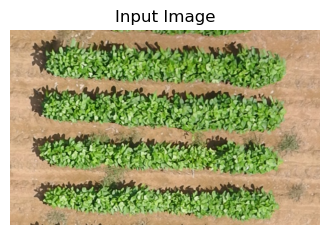

In [8]:
img = Image.open(r"C:\Popat Pawar\2025UAS\Laavanya\Deep learning\2025\08072025_STU\project\data\images\25DIV3FAY_1002.jpg").convert('RGB')
x = transform(img).unsqueeze(0)

plt.figure(figsize=(4,4))
plt.imshow(img)
plt.axis('off')
plt.title('Input Image')
plt.show()


## Forward pass and embedding extraction

The image now goes through the network.
The result is a **512‑dimensional embedding**.


In [9]:
with torch.no_grad():
    embedding = model(x).squeeze().numpy()

print('Embedding shape:', embedding.shape)


Embedding shape: (512,)


## Select representative feature maps

Each layer has many feature maps. We show only a few examples to keep
the visualization readable.


In [10]:
def representative_maps(fmap, n=3):
    fmap = fmap.squeeze(0)
    C = fmap.shape[0]
    idxs = np.linspace(0, C - 1, n, dtype=int)
    maps = []
    for i in idxs:
        fm = fmap[i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-6)
        maps.append(fm)
    return maps


## Layer‑wise visualization

This diagram shows how the image representation changes as it moves
through the network layers, ending in a numerical embedding.


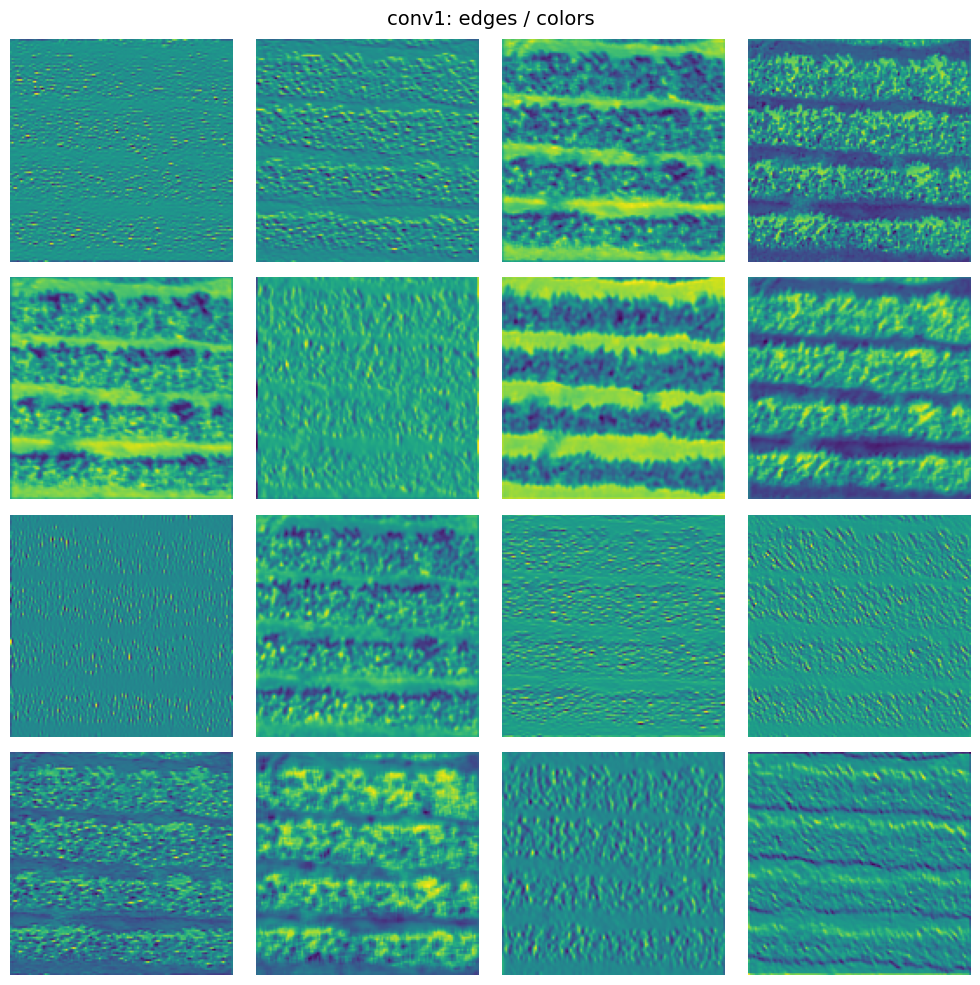

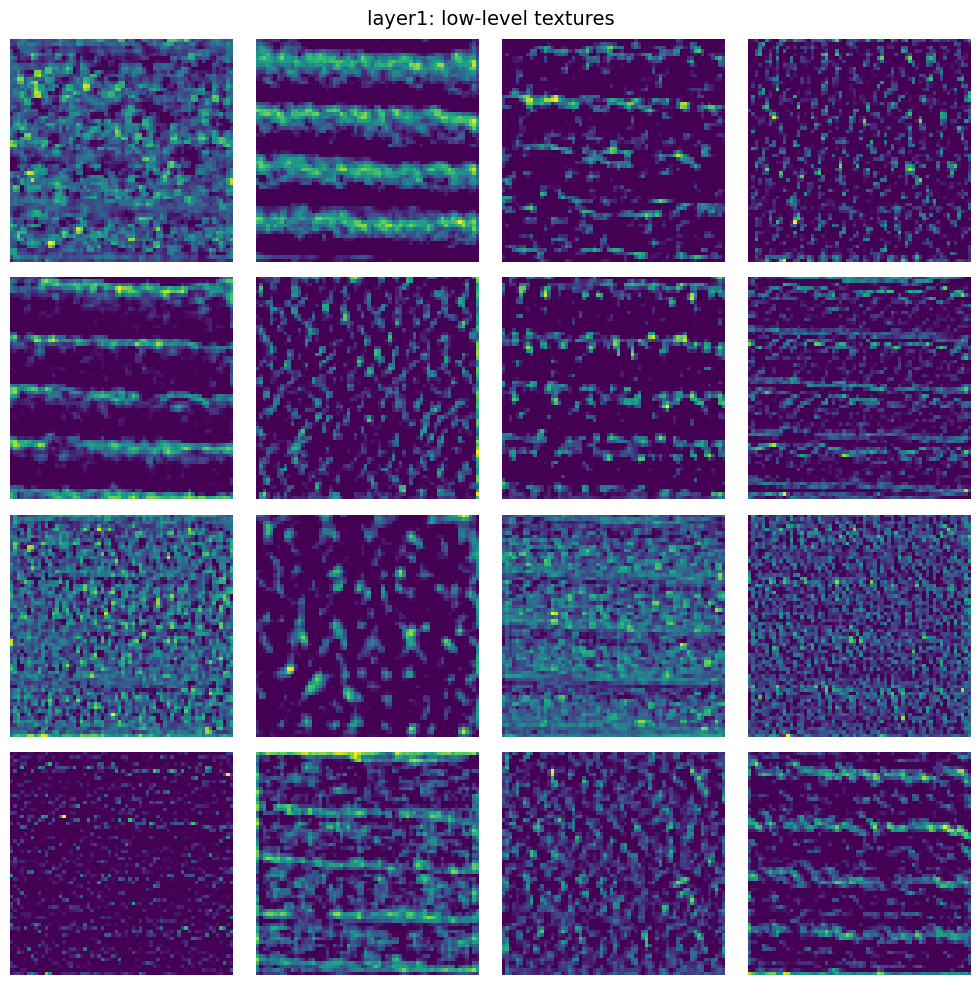

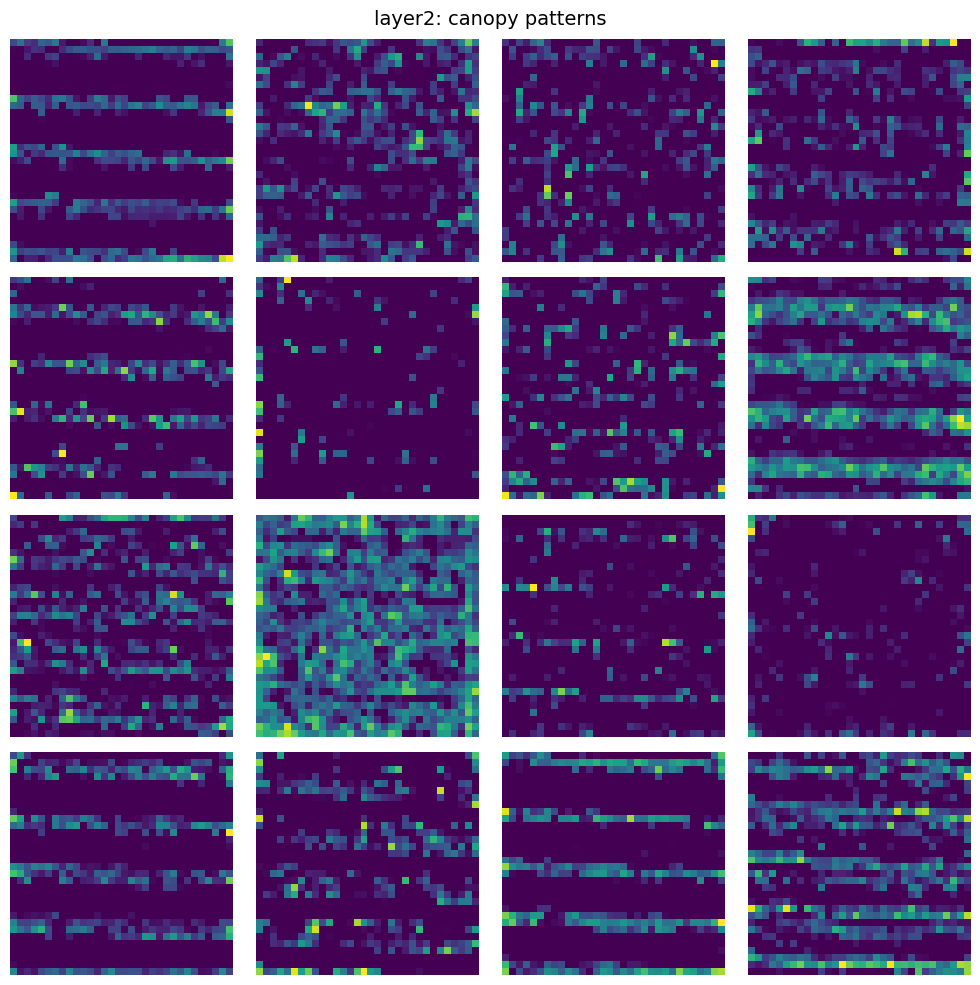

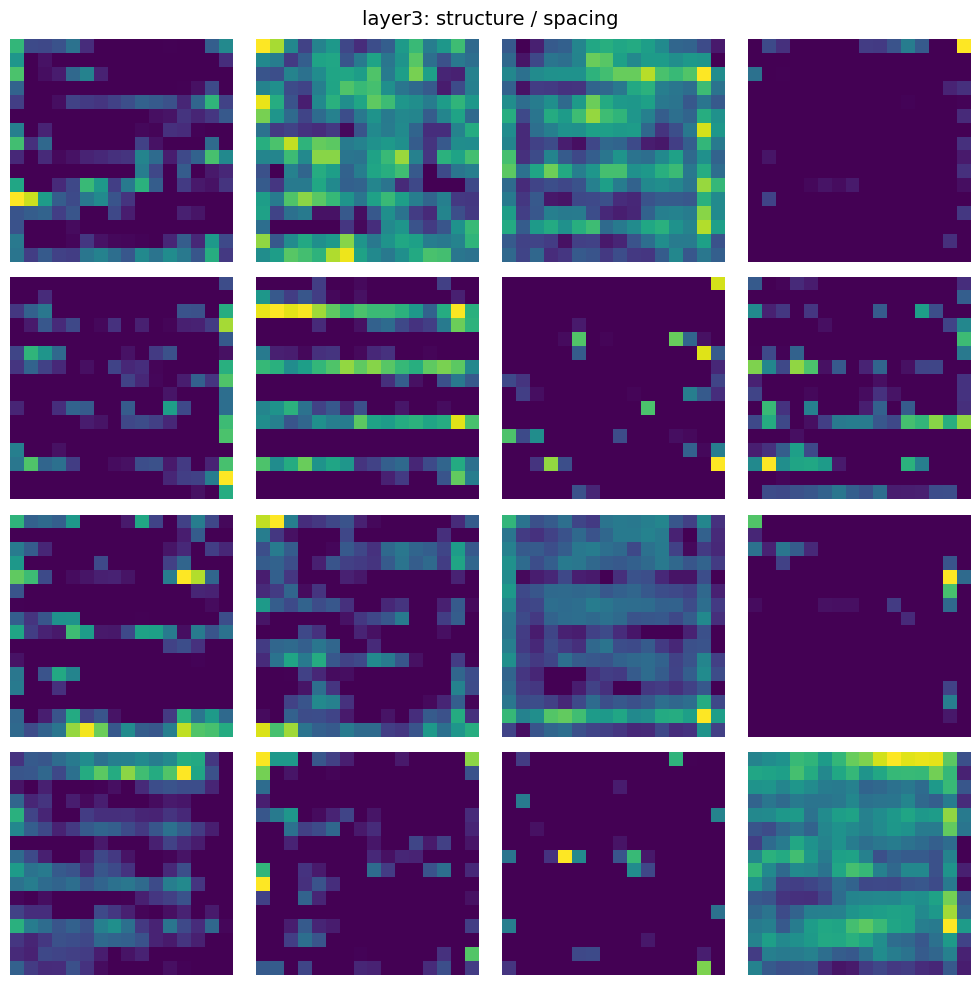

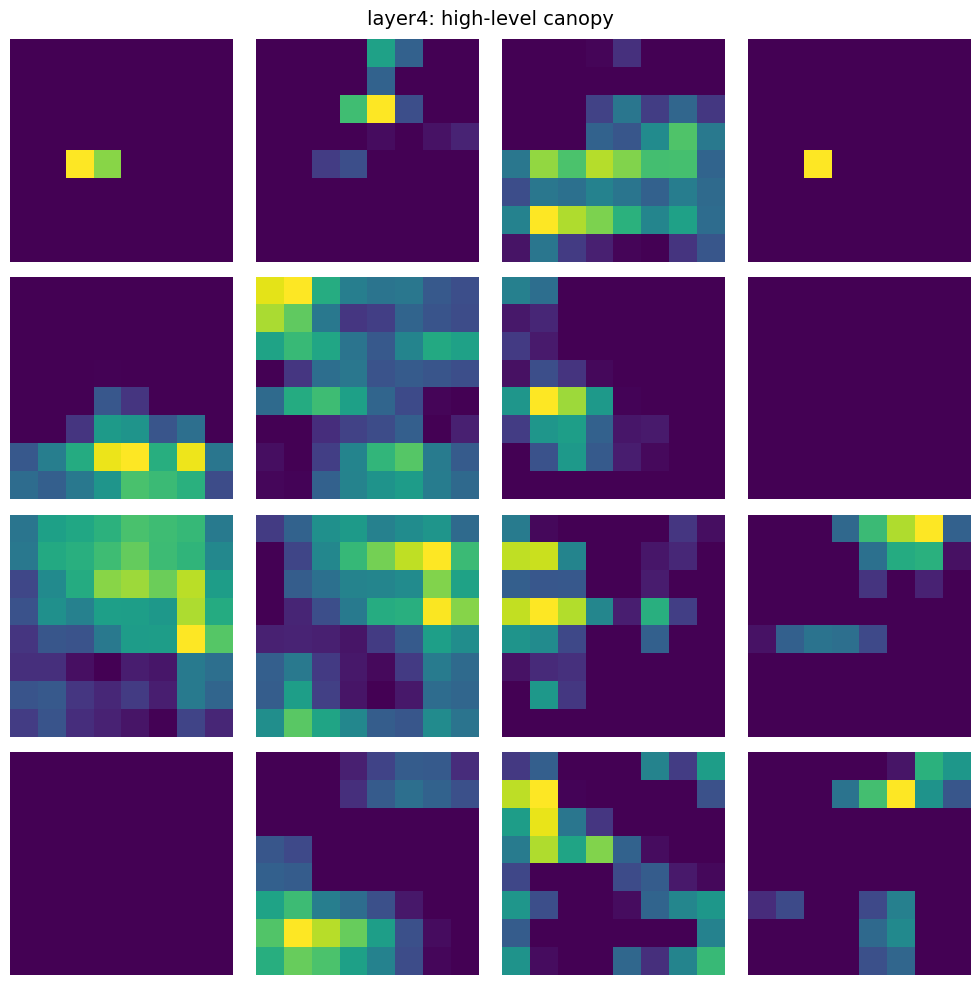

In [15]:
# =========================================================
# 6. VISUALIZATION FUNCTION
# =========================================================
def visualize_feature_maps(fmap, title, max_channels=16):
    fmap = fmap.squeeze(0)  # [C, H, W]

    num_channels = min(fmap.shape[0], max_channels)
    grid_size = math.ceil(math.sqrt(num_channels))

    plt.figure(figsize=(10, 10))

    for i in range(num_channels):
        plt.subplot(grid_size, grid_size, i + 1)
        fm = fmap[i]

        # normalize per-channel
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-6)

        plt.imshow(fm, cmap="viridis")
        plt.axis("off")

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()

# =========================================================
# 7. VISUALIZE
# =========================================================
visualize_feature_maps(feature_maps["conv1"],  "conv1: edges / colors")
visualize_feature_maps(feature_maps["layer1"], "layer1: low-level textures")
visualize_feature_maps(feature_maps["layer2"], "layer2: canopy patterns")
visualize_feature_maps(feature_maps["layer3"], "layer3: structure / spacing")
visualize_feature_maps(feature_maps["layer4"], "layer4: high-level canopy")

In [22]:
feature_maps = {}

def save_hook(name):
    def hook(module, inp, out):
        feature_maps[name] = out.detach().cpu()
    return hook

# Register hooks for ALL conv layers
model.conv1.register_forward_hook(save_hook("conv1"))

for i, block in enumerate(model.layer1):
    block.conv1.register_forward_hook(save_hook(f"layer1.{i}.conv1"))
    block.conv2.register_forward_hook(save_hook(f"layer1.{i}.conv2"))

for i, block in enumerate(model.layer2):
    block.conv1.register_forward_hook(save_hook(f"layer2.{i}.conv1"))
    block.conv2.register_forward_hook(save_hook(f"layer2.{i}.conv2"))

for i, block in enumerate(model.layer3):
    block.conv1.register_forward_hook(save_hook(f"layer3.{i}.conv1"))
    block.conv2.register_forward_hook(save_hook(f"layer3.{i}.conv2"))

for i, block in enumerate(model.layer4):
    block.conv1.register_forward_hook(save_hook(f"layer4.{i}.conv1"))
    block.conv2.register_forward_hook(save_hook(f"layer4.{i}.conv2"))

In [23]:
transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(256),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225],
    ),
])

img = Image.open(
    r"C:\Popat Pawar\2025UAS\Laavanya\Deep learning\2025\08072025_STU\project\data\images\25DIV3FAY_1001.jpg"
).convert("RGB")

x = transform(img).unsqueeze(0).to(device)

with torch.no_grad():
    embedding = model(x).squeeze().cpu().numpy()

In [24]:
def representative_maps(fmap, n=4):
    # fmap: [1,C,H,W]
    fmap = fmap.squeeze(0)
    C = fmap.shape[0]

    idxs = np.linspace(0, C-1, n, dtype=int)
    maps = []

    for i in idxs:
        fm = fmap[i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-6)
        maps.append(fm)

    return maps

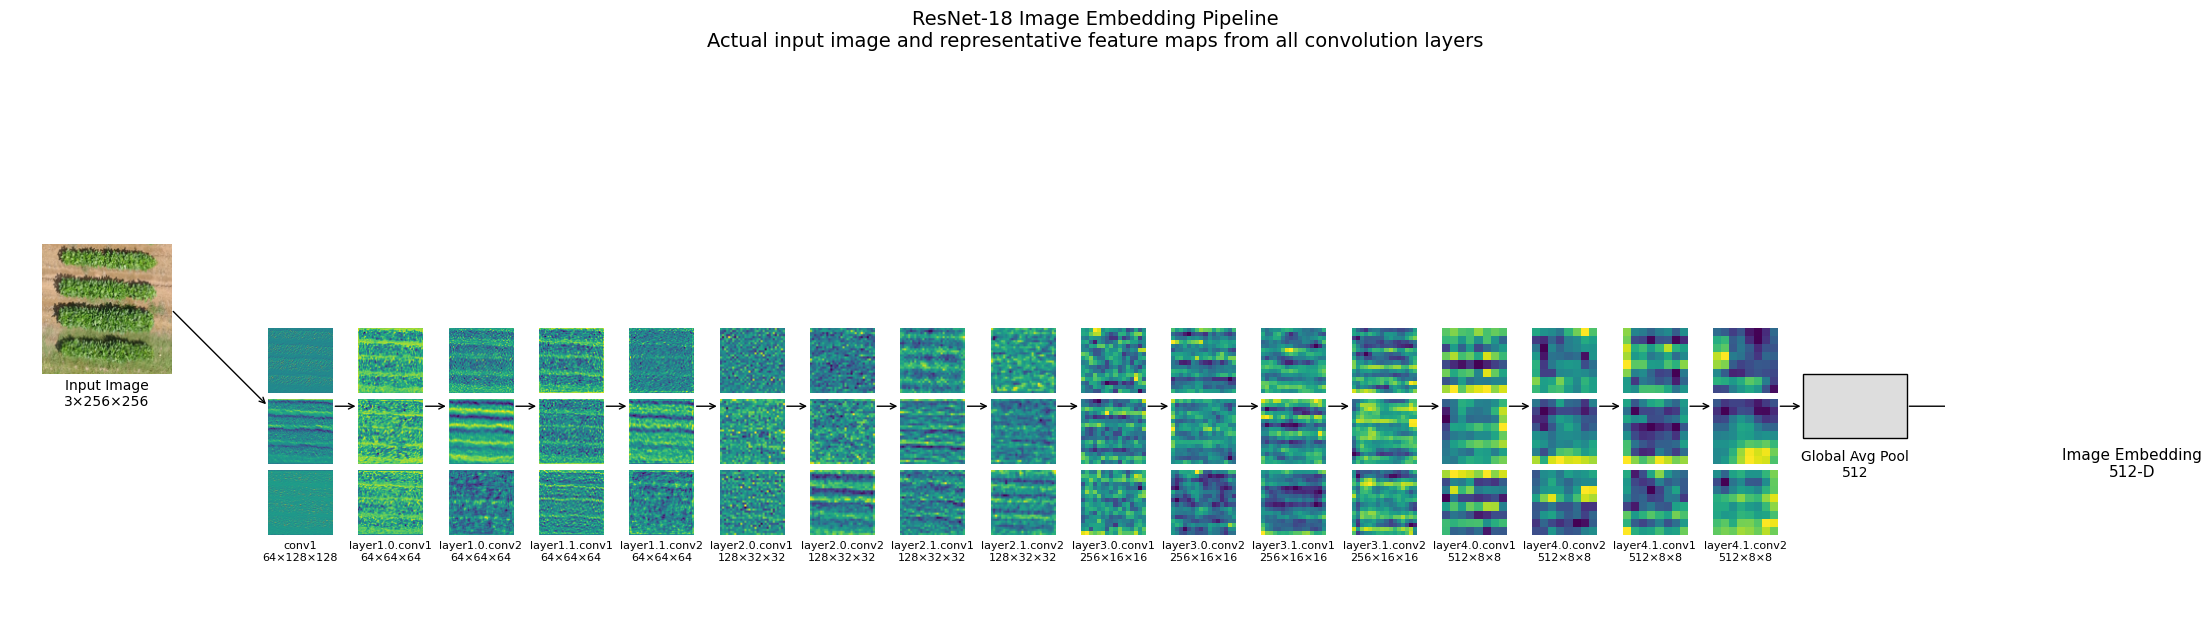

In [26]:
layer_order = [
    "conv1",

    "layer1.0.conv1", "layer1.0.conv2",
    "layer1.1.conv1", "layer1.1.conv2",

    "layer2.0.conv1", "layer2.0.conv2",
    "layer2.1.conv1", "layer2.1.conv2",

    "layer3.0.conv1", "layer3.0.conv2",
    "layer3.1.conv1", "layer3.1.conv2",

    "layer4.0.conv1", "layer4.0.conv2",
    "layer4.1.conv1", "layer4.1.conv2",
]
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch
import numpy as np

def draw_arrow(ax, x1, y1, x2, y2):
    ax.add_patch(
        FancyArrowPatch(
            (x1, y1), (x2, y2),
            arrowstyle="->",
            linewidth=1.0,
            mutation_scale=10,
            color="black"
        )
    )
def representative_maps(fmap, n=4):
    fmap = fmap.squeeze(0)
    C = fmap.shape[0]
    idxs = np.linspace(0, C-1, n, dtype=int)

    maps = []
    for i in idxs:
        fm = fmap[i]
        fm = (fm - fm.min()) / (fm.max() - fm.min() + 1e-6)
        maps.append(fm.numpy())
    return maps

fig, ax = plt.subplots(figsize=(22, 7))
ax.axis("off")
ax.set_xlim(0, 30)
ax.set_ylim(0, 8)

# ---------------------------
# Input image
# ---------------------------
ax.imshow(img.resize((128, 128)), extent=(0.5, 2.5, 4, 6))
ax.text(1.5, 3.5, "Input Image\n3×256×256", ha="center", fontsize=10)

prev_x = 2.5
prev_y = 5.0
x = 4.0

# ---------------------------
# Iterate over conv layers
# ---------------------------
for lname in layer_order:
    fmap = feature_maps[lname]
    C, H, W = fmap.shape[1:]

    reps = representative_maps(fmap, n=3)

    # plot representative feature maps
    for i, fm in enumerate(reps):
        ax.imshow(
            fm,
            extent=(x, x+1.0, 1.5 + i*1.1, 2.5 + i*1.1),
            cmap="viridis"
        )

    # layer label
    ax.text(
        x+0.5, 1.1,
        f"{lname}\n{C}×{H}×{W}",
        ha="center", fontsize=8
    )

    # arrow
    draw_arrow(ax, prev_x, prev_y, x, 3.5)

    prev_x = x+1.0
    prev_y = 3.5
    x += 1.4

# ---------------------------
# Global Average Pooling
# ---------------------------
draw_arrow(ax, prev_x, prev_y, x, prev_y)
ax.add_patch(plt.Rectangle((x, 3.0), 1.6, 1.0,
                           fc="#dddddd", ec="black"))
ax.text(x+0.8, 2.4, "Global Avg Pool\n512", ha="center", fontsize=10)

# ---------------------------
# Embedding vector
# ---------------------------
draw_arrow(ax, x+1.6, prev_y, x+3.6, prev_y)
ax.add_patch(plt.Rectangle((x+3.6, 3.0), 3.0, 1.0,
                           fc="#cccccc", ec="black"))
ax.text(
    x+5.1, 2.4,
    "Image Embedding\n512‑D",
    ha="center", fontsize=11
)

plt.suptitle(
    "ResNet‑18 Image Embedding Pipeline\n"
    "Actual input image and representative feature maps from all convolution layers",
    fontsize=14
)
plt.tight_layout()
plt.show()

## Store embedding as a table

We convert the embedding into a table so it can be saved and reused.


In [27]:
df_embedding = pd.DataFrame([
    embedding
], columns=[f'emb_{i}' for i in range(len(embedding))])
df_embedding.insert(0, 'image_id', 'example_image.jpg')
df_embedding


,image_id,emb_0,emb_1,emb_2,emb_3,emb_4,emb_5,emb_6,emb_7,emb_8,...,emb_502,emb_503,emb_504,emb_505,emb_506,emb_507,emb_508,emb_509,emb_510,emb_511
0,example_image.jpg,0.001481,0.0,0.120771,0.0,0.239412,0.392026,0.0,0.040675,1.443557,...,2.845206,0.0,0.0,0.926134,0.027961,0.817674,0.502926,0.081858,0.0,0.072304


## Save embedding to CSV

This allows the embedding to be downloaded and reused without rerunning the model.


In [ ]:
df_embedding.to_csv('image_embedding.csv', index=False)
print('Embedding saved to image_embedding.csv')
